<a href="https://colab.research.google.com/github/zohaibahmedshaikh32-coder/Health-Risk-Classification-/blob/main/Health_Risk_Classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Health Risk Classification|24f-AI-211 |Section:C

Dataset successfully loaded!
First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               

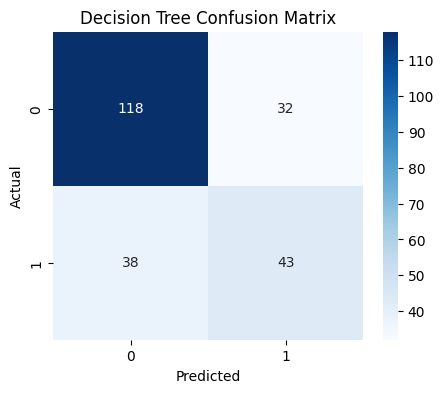

 SVM CLASSIFIER (RBF KERNEL)
Training Accuracy: 84.17 %
Testing Accuracy: 74.03 %

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       150
           1       0.67      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.69       231
weighted avg       0.73      0.74      0.73       231



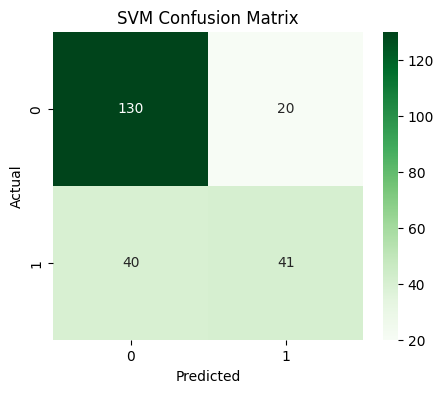

FINAL PERFORMANCE COMPARISON 
              Model  Train Accuracy (%)  Test Accuracy (%)
0     Decision Tree              100.00              69.70
1  SVM (RBF Kernel)               84.17              74.03


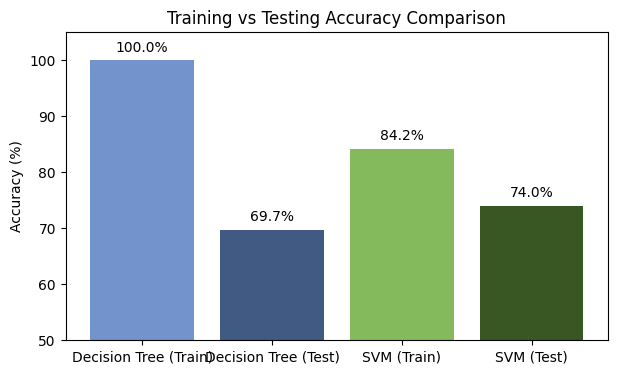

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#load dataset
import pandas as pd
import numpy as np

# Direct raw link to Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names for the dataset
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("Dataset successfully loaded!")
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# PREPROESSING & CLEANING
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing complete. Training shape:", X_train_scaled.shape, "| Testing shape:", X_test_scaled.shape)

# DECISION TREE CLASSIFIER
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
dt_train_acc = accuracy_score(y_train, y_train_pred_dt)
dt_test_acc = accuracy_score(y_test, y_test_pred_dt)

print("DECISION TREE CLASSIFIER RESULTS")
print("Training Accuracy:", round(dt_train_acc * 100, 2), "%")
print("Testing Accuracy:", round(dt_test_acc * 100, 2), "%")
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred_dt))

# Confusion Matrix plot for Decision Tree
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# SUPPORT VECTOR MACHINE(Svm)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
svm_train_acc = accuracy_score(y_train, y_train_pred_svm)
svm_test_acc = accuracy_score(y_test, y_test_pred_svm)

print(" SVM CLASSIFIER (RBF KERNEL)")
print("Training Accuracy:", round(svm_train_acc * 100, 2), "%")
print("Testing Accuracy:", round(svm_test_acc * 100, 2), "%")
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred_svm))

# Confusion Matrix plot for SVM
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# MODEL COMPARISON & SUMMARY
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'SVM (RBF Kernel)'],
    'Train Accuracy (%)': [round(dt_train_acc * 100, 2), round(svm_train_acc * 100, 2)],
    'Test Accuracy (%)': [round(dt_test_acc * 100, 2), round(svm_test_acc * 100, 2)]
})

print("FINAL PERFORMANCE COMPARISON ")
print(results_df)

# Plotting Accuracy Comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(['Decision Tree (Train)', 'Decision Tree (Test)', 'SVM (Train)', 'SVM (Test)'],
               [dt_train_acc*100, dt_test_acc*100, svm_train_acc*100, svm_test_acc*100],
               color=['#7293CB', '#415A83', '#84BA5B', '#385723'])
plt.ylabel('Accuracy (%)')
plt.title('Training vs Testing Accuracy Comparison')
plt.ylim(50, 105)

# Adding accuracy values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{round(yval, 1)}%', ha='center', va='bottom')

plt.show()